## DIAObject duplication

Eric Bellm, 2025-03-03



In [49]:
import lsst.afw.display
import lsst.daf.butler
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import lsst.geom as geom

In [11]:
collection = 'LSSTCam/prompt/output-2025-11-04'
#collection = 'u/elhoward/DM-52372/w33_drp/template_coadd-QC/test2'
#collection = 'u/elhoward/DM-52372/w33_drp/template_coadd-QC/test_2396'

butler = lsst.daf.butler.Butler("embargo", collections=collection)

https://usdf-rsp.slac.stanford.edu/portal/app/onlinehelp/#id=visualization.fitsViewer

In [12]:

#sc = SkyCoord('4h19m54.62s -48d24m12.8s', unit=('hourangle','deg'))
#sc = SkyCoord('4h19m57.58s -48d25m20.8s', frame='icrs') # test edges
sc = SkyCoord('4h14m01.19s -48d22m45.9s', frame='icrs') # test grid
ra = sc.ra.degree
dec = sc.dec.degree
band = "'z'"

In [13]:
#refs = butler.query_datasets('difference_image')
refs = butler.query_datasets('preloaded_dia_object',  where=f'visit_detector_region.region OVERLAPS POINT({ra}, {dec}) and band={band}')

In [14]:
len(refs)

938

In [30]:
for ref in refs:
    diaObject = butler.get(ref)
    if len(diaObject) > 1000:
        print(len(diaObject), ref.dataId)

2052 {instrument: 'LSSTCam', detector: 49, group: '2025-11-05T05:07:55.831'}
1582 {instrument: 'LSSTCam', detector: 107, group: '2025-11-05T05:15:37.099'}
1545 {instrument: 'LSSTCam', detector: 114, group: '2025-11-05T05:16:15.671'}
1631 {instrument: 'LSSTCam', detector: 61, group: '2025-11-05T05:07:57.137'}
2066 {instrument: 'LSSTCam', detector: 49, group: '2025-11-05T05:07:57.137'}
1245 {instrument: 'LSSTCam', detector: 58, group: '2025-11-05T05:15:37.099'}
1860 {instrument: 'LSSTCam', detector: 61, group: '2025-11-05T05:15:37.099'}
1680 {instrument: 'LSSTCam', detector: 49, group: '2025-11-05T05:16:15.671'}
1184 {instrument: 'LSSTCam', detector: 61, group: '2025-11-05T05:16:15.671'}
1950 {instrument: 'LSSTCam', detector: 61, group: '2025-11-05T05:07:55.831'}
1843 {instrument: 'LSSTCam', detector: 107, group: '2025-11-05T05:07:55.831'}
1506 {instrument: 'LSSTCam', detector: 58, group: '2025-11-05T05:07:57.137'}
1673 {instrument: 'LSSTCam', detector: 58, group: '2025-11-05T05:07:55.83

In [50]:
diaObject = butler.get('preloaded_dia_object', dataId = 
                       {'instrument': 'LSSTCam', 'detector': 49, 'group': '2025-11-05T05:07:55.831', 
                       'skymap': 'lsst_cells_v1'})
len(diaObject)

2052

In [52]:
diaObject[['ra','dec']]

ra,dec
float64,float64
9.009500945061447,-44.29842026323954
8.972826050741954,-44.27449635305771
8.999755987633632,-44.28049320070076
8.991249956704829,-44.27868440122136
8.973321561091554,-44.30322146896885
8.974889150689584,-44.2874591039289
8.970157826941197,-44.29013228188783
8.998575380666058,-44.28355354858158
8.984438850121174,-44.282736881244105


In [46]:
butler_embargo = lsst.daf.butler.Butler("embargo",collections='LSSTCam/defaults')
skymap = butler_embargo.get('skyMap', skymap='lsst_cells_v1')

In [54]:

raDeg = 9.009500945061447
decDeg = -44.29842026323954
point = geom.SpherePoint(raDeg, decDeg, geom.degrees)
coordList = [point]
tractPatchList = skymap.findTractPatchList(coordList)
for tractPatch in tractPatchList:
    tract = tractPatch[0]
    patchInfo = tractPatch[1]
    for patch in patchInfo:
        print(tract.tract_id, patch.sequential_index)

2876 21
2877 29


In [67]:
diaObject

diaObjectId,validityStartMjdTai,validityEndMjdTai,ra,raErr,dec,decErr,ra_dec_Cov,u_psfFluxMean,u_psfFluxMeanErr,u_psfFluxSigma,u_psfFluxNdata,u_fpFluxMean,u_fpFluxMeanErr,g_psfFluxMean,g_psfFluxMeanErr,g_psfFluxSigma,g_psfFluxNdata,g_fpFluxMean,g_fpFluxMeanErr,r_psfFluxMean,r_psfFluxMeanErr,r_psfFluxSigma,r_psfFluxNdata,r_fpFluxMean,r_fpFluxMeanErr,i_psfFluxMean,i_psfFluxMeanErr,i_psfFluxSigma,i_psfFluxNdata,i_fpFluxMean,i_fpFluxMeanErr,z_psfFluxMean,z_psfFluxMeanErr,z_psfFluxSigma,z_psfFluxNdata,z_fpFluxMean,z_fpFluxMeanErr,y_psfFluxMean,y_psfFluxMeanErr,y_psfFluxSigma,y_psfFluxNdata,y_fpFluxMean,y_fpFluxMeanErr,u_scienceFluxMean,u_scienceFluxMeanErr,g_scienceFluxMean,g_scienceFluxMeanErr,r_scienceFluxMean,r_scienceFluxMeanErr,i_scienceFluxMean,i_scienceFluxMeanErr,z_scienceFluxMean,z_scienceFluxMeanErr,y_scienceFluxMean,y_scienceFluxMeanErr,u_psfFluxMin,u_psfFluxMax,u_psfFluxMaxSlope,u_psfFluxErrMean,g_psfFluxMin,g_psfFluxMax,g_psfFluxMaxSlope,g_psfFluxErrMean,r_psfFluxMin,r_psfFluxMax,r_psfFluxMaxSlope,r_psfFluxErrMean,i_psfFluxMin,i_psfFluxMax,i_psfFluxMaxSlope,i_psfFluxErrMean,z_psfFluxMin,z_psfFluxMax,z_psfFluxMaxSlope,z_psfFluxErrMean,y_psfFluxMin,y_psfFluxMax,y_psfFluxMaxSlope,y_psfFluxErrMean,firstDiaSourceMjdTai,lastDiaSourceMjdTai,nDiaSources,__index_level_0__
int64,float64,float64,float64,float32,float64,float32,float32,float32,float32,float32,int32,float32,float32,float32,float32,float32,int32,float32,float32,float32,float32,float32,int32,float32,float32,float32,float32,float32,int32,float32,float32,float32,float32,float32,int32,float32,float32,float32,float32,float32,int32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,int32,int64
169302852974936262,60925.27284491163,--,9.009500945061447,2.1921383e-05,-44.29842026323954,3.3304685e-05,2.9349058e-11,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,1,169302852974936262
169342392331141155,60934.12519409685,--,8.972826050741954,4.6996705e-05,-44.27449635305771,7.093967e-05,3.9000025e-10,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,1,169342392331141155
169342392463786032,60937.26688054582,--,8.999755987633632,2.4618499e-05,-44.28049320070076,4.171282e-05,2.5941044e-10,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,2,169342392463786032
169342393940705320,60934.130861873564,--,8.991249956704829,6.2382955e-05,-44.27868440122136,7.5192285e-05,-9.172896e-11,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,1,169342393940705320
169355604163297312,60937.26138127133,--,8.973321561091554,0.00012874669,-44.30322146896885,0.00019040753,2.5005265e-09,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,1,169355604163297312
169355604163297319,60937.26138127133,--,8.974889150689584,0.0001289782,-44.2874591039289,0.00012305492,-1.1104277e-08,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,-

In [45]:
# make this a pandas dataframe to match what we get from the APDB

In [68]:
diaObject = diaObject.to_pandas()

In [69]:
diaObject['nDiaSources'].max()

17

In [70]:
sc = SkyCoord(diaObject['ra'], diaObject['dec'], unit='deg', frame='icrs')

In [71]:
# self-crossmatch, taking the second closed match
idx, d2d, d3d = sc.match_to_catalog_sky(sc, nthneighbor=2)

In [72]:
# define a forward index
fidx = np.arange(len(idx))

In [90]:
d2d

<Angle [0.00680671, 0.00079605, 0.0026234 , ..., 0.00049532, 0.0004515 ,
        0.00130439] deg>

Text(0, 0.5, 'Number of DiaObjects')

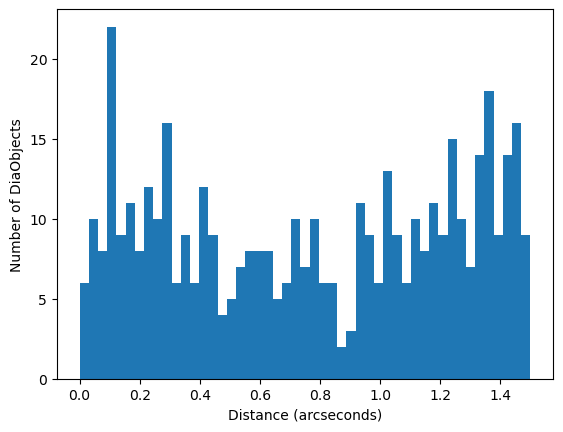

In [103]:
plt.figure()
plt.hist(d2d.to(u.arcsecond).value,bins=np.linspace(0,1.5,50))
plt.xlabel('Distance (arcseconds)')
plt.ylabel('Number of DiaObjects')

In [104]:
wdup = d2d < 0.5*u.arcsecond

In [105]:
np.sum(wdup)

np.int64(158)

In [106]:
diaObject.iloc[wdup]

,diaObjectId,validityStartMjdTai,validityEndMjdTai,ra,raErr,dec,decErr,ra_dec_Cov,u_psfFluxMean,u_psfFluxMeanErr,...,z_psfFluxMaxSlope,z_psfFluxErrMean,y_psfFluxMin,y_psfFluxMax,y_psfFluxMaxSlope,y_psfFluxErrMean,firstDiaSourceMjdTai,lastDiaSourceMjdTai,nDiaSources,__index_level_0__
35,169298437058068525,60924.367904,NaN,8.824821,0.000023,-44.492747,0.000032,4.139277e-11,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,169298437058068525
36,169298437209063453,60924.368370,NaN,8.824905,0.000026,-44.492753,0.000036,-2.048233e-10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,169298437209063453
46,169355603655786617,60937.257862,NaN,8.821833,0.000019,-44.523721,0.000028,-3.336417e-11,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,169355603655786617
47,169355603789480106,60937.258386,NaN,8.821682,0.000039,-44.523685,0.000052,2.019680e-10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,169355603789480106
62,169342390824861911,60934.118633,NaN,8.823154,0.000020,-44.369962,0.000028,6.636725e-12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,169342390824861911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1962,169355603763789944,60937.258312,NaN,9.089161,0.000016,-44.309030,0.000025,-1.142924e-10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,169355603763789944
1984,169342390825386454,60934.122867,NaN,9.015898,0.000018,-44.322547,0.000022,9.204654e-11,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,169342390825386454
1985,169342391098015934,60940.097459,NaN,9.015990,0.000027,-44.322610,0.000034,2.480212e-10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,169342391098015934
2006,169355604840677820,60937.263515,NaN,9.053645,0.000285,-44.339141,0.000246,-3.139724e-08,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,169355604840677820


In [107]:
fidx[wdup]

array([  35,   36,   46,   47,   62,   63,   64,   66,  115,  116,  118,
        120,  145,  146,  148,  156,  159,  179,  180,  200,  201,  210,
        211,  212,  215,  216,  244,  245,  254,  258,  265,  266,  268,
        270,  322,  325,  333,  335,  352,  353,  364,  365,  406,  409,
        456,  457,  459,  463,  471,  472,  625,  626,  627,  629,  634,
        636,  641,  643,  653,  654,  681,  682,  715,  718,  744,  745,
        762,  763,  828,  829,  830,  831,  846,  847,  857,  863,  889,
        891,  895,  896,  933,  934,  936,  937,  938,  941,  989,  990,
       1079, 1082, 1084, 1085, 1087, 1091, 1098, 1119, 1123, 1124, 1134,
       1135, 1179, 1180, 1181, 1241, 1242, 1243, 1261, 1263, 1264, 1265,
       1274, 1275, 1340, 1343, 1344, 1346, 1347, 1455, 1456, 1457, 1458,
       1460, 1483, 1484, 1485, 1486, 1487, 1488, 1570, 1572, 1576, 1577,
       1600, 1601, 1602, 1603, 1635, 1637, 1639, 1701, 1702, 1739, 1741,
       1744, 1746, 1747, 1748, 1749, 1820, 1823, 18

In [108]:
idx[wdup]

array([  36,   35,   47,   46,   66,   66,   66,   62,  118,  120,  120,
        118,  146,  145,  145,  159,  156,  180,  179,  201,  200,  215,
        210,  215,  212,  210,  245,  244,  258,  254,  268,  270,  265,
        266,  325,  322,  335,  333,  353,  352,  365,  364,  409,  406,
        459,  463,  456,  457,  472,  471,  626,  625,  626,  625,  636,
        634,  643,  641,  654,  653,  682,  681,  718,  715,  745,  744,
        763,  762,  829,  828,  831,  830,  847,  846,  863,  857,  891,
        889,  896,  895,  936,  938,  933,  941,  934,  937,  990,  989,
       1091, 1091, 1085, 1079, 1085, 1079, 1087, 1123, 1119, 1119, 1135,
       1134, 1181, 1181, 1180, 1242, 1241, 1241, 1263, 1261, 1265, 1264,
       1275, 1274, 1347, 1344, 1346, 1344, 1340, 1458, 1458, 1460, 1455,
       1457, 1486, 1486, 1488, 1484, 1484, 1485, 1572, 1570, 1577, 1576,
       1603, 1603, 1600, 1601, 1637, 1635, 1637, 1702, 1701, 1744, 1739,
       1739, 1749, 1748, 1747, 1746, 1823, 1820, 18

In [109]:
# find unique pairs of duplicates
# pairs = list(zip(fidx[wdup], idx[wdup]))

In [110]:
pairs = []
for a, b in zip(fidx[wdup], idx[wdup]):
    if a < b:
        pairs.append((a,b))
    else:
        pairs.append((b,a))

In [111]:
np.unique(np.array(pairs), axis=0)

array([[  35,   36],
       [  46,   47],
       [  62,   66],
       [  63,   66],
       [  64,   66],
       [ 115,  118],
       [ 116,  120],
       [ 118,  120],
       [ 145,  146],
       [ 145,  148],
       [ 156,  159],
       [ 179,  180],
       [ 200,  201],
       [ 210,  211],
       [ 210,  215],
       [ 210,  216],
       [ 212,  215],
       [ 244,  245],
       [ 254,  258],
       [ 265,  268],
       [ 266,  270],
       [ 322,  325],
       [ 333,  335],
       [ 352,  353],
       [ 364,  365],
       [ 406,  409],
       [ 456,  459],
       [ 457,  463],
       [ 471,  472],
       [ 625,  626],
       [ 625,  629],
       [ 626,  627],
       [ 634,  636],
       [ 641,  643],
       [ 653,  654],
       [ 681,  682],
       [ 715,  718],
       [ 744,  745],
       [ 762,  763],
       [ 828,  829],
       [ 830,  831],
       [ 846,  847],
       [ 857,  863],
       [ 889,  891],
       [ 895,  896],
       [ 933,  936],
       [ 934,  938],
       [ 937,